# Tesis — Solución 1.3 (desacoplada) y Solución 1.2 (acoplada)




## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


## Sponge factor (corregido, común a ambos sistemas)

$\eta(x) = \eta_0 \cdot \mathrm{clip}\!\left(\dfrac{|x|-(L-w)}{w},\,0,\,1\right)^2$

Cero en el interior, crece cuadráticamente desde $|x|=L-w$ hasta $\eta_0$ en el borde $|x|=L$. (La versión anterior usaba una Gaussiana centrada en $0.85L$ que quedaba **más débil justo en el borde** que un poco antes — invertido respecto a lo que necesita un sponge.)

In [2]:
def construir_sponge(x, L, w=6.0, eta0=3.0):
    """
    eta(x): 0 en el interior, crece cuadraticamente hasta eta0 en el borde.
    Empieza en |x| = L - w. Monotona creciente hacia |x| = L.
    """
    return eta0 * np.clip((np.abs(x) - (L - w)) / w, 0.0, 1.0) ** 2


# Solución 1.3 — Caso desacoplado ($\phi=0$)

Simulación numérica siguiendo la metodología de Di Menza (2007), Sección 6.1.

**Sistema:** $i\partial_t\psi = \partial_{xx}\psi + \psi(1-|\psi|^2)$

**Solución exacta:** $\psi(x,t) = A_1\tanh(b(x-ct)) + iB_1$, con
$A_1^2 = 1-c^2/2$, $b^2=(2-c^2)/4$, $B_1=-c/\sqrt{2}$, existencia $|c|<\sqrt{2}$.

## Grilla espacial (Sol. 1.3)

In [3]:
def construir_grilla_13(L=40, N=800, w=6.0, eta0=3.0):
    x = np.linspace(-L, L, N)
    h = x[1] - x[0]
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    return x, h, eta


## Grilla temporal

In [4]:
def construir_grilla_temporal(T=50, dt=0.005):
    return np.arange(0, T, dt)


## Solución 1.3 — Parámetros analíticos y solución exacta

$$B_1 = -\frac{c}{\sqrt{2}}, \quad b = \frac{\sqrt{2-c^2}}{2}, \quad A_1 = \sqrt{1-\frac{c^2}{2}}$$

In [5]:
def parametros_sol13(c):
    """
    (A1, b, B1) para la Solucion 1.3 (caso desacoplado, phi=0).
    Existencia: |c| < sqrt(2). Fuera de la region devuelve nan/0.0 con [aviso]
    (mismo criterio que parametros_sol12), en vez de lanzar una excepcion.
    """
    A1sq = 1 - c**2/2
    b2   = (2 - c**2)/4
    if b2   <= 0: print(f"[aviso] b^2={b2:.3g} <= 0 -> |c| >= sqrt(2), fuera de existencia.")
    if A1sq <= 0: print(f"[aviso] A1^2={A1sq:.3g} <= 0 -> fondo oscuro degenerado.")
    b  = np.sqrt(b2)   if b2   > 0 else np.nan
    A1 = np.sqrt(A1sq) if A1sq > 0 else 0.0
    B1 = -c/np.sqrt(2)          # lineal en c -> conserva el signo (rama -i)
    return A1, b, B1


def solucion_exacta13(x, par, c, t):
    """psi_sol(x,t) = A1*tanh(b*(x-ct)) + i*B1.  Recibe par ya calculado."""
    A1, b, B1 = par
    return A1*np.tanh(b*(x - c*t)) + 1j*B1


def matriz_solucion_exacta13(x, par, c, t):
    """psi_sol para todos los instantes t. Devuelve (Nt, Nx), dtype complex."""
    sol = np.zeros((len(t), len(x)), dtype=complex)
    for i in range(len(t)):
        sol[i, :] = solucion_exacta13(x, par, c, t[i])
    return sol

## Funciones auxiliares

In [6]:
def segunda_derivada(U, h):
    """
    d2U/dx2 por diferencias finitas centradas, O(h^2).
    U puede ser vector (Nx,) o matriz (Nt, Nx) -- usa ... (ellipsis).
    """
    U_xx = np.zeros_like(U)
    U_xx[..., 1:-1] = (U[..., 2:] - 2*U[..., 1:-1] + U[..., :-2]) / h**2
    return U_xx


def norma_L2(U, h):
    """N = h*sum(|U_j|^2) -- norma discreta L2."""
    return h * np.sum(np.abs(U)**2, axis=-1)


def masa_defecto(U, h):
    """M = h*sum(1-|U_j|^2) -- cantidad conservada para dark solitons."""
    return h * np.sum(1 - np.abs(U)**2, axis=-1)


def residuo(U, h, c=0.0):
    """
    Residuo de la EDO de onda viajera:
        i*c*U' + d2_xx U + U*(1-|U|^2)
    (para c=0 se reduce a d2_xx U + U*(1-|U|^2)).
    Debe ser ~0 si U es la solucion exacta solucion_exacta13(x,c,t).
    NOTA: la version anterior omitia el termino i*c*U', por lo que daba
    residuo grande y enganoso para cualquier c != 0.
    """
    U_x = np.zeros_like(U)
    U_x[..., 1:-1] = (U[..., 2:] - U[..., :-2]) / (2*h)
    return 1j*c*U_x + segunda_derivada(U, h) + U * (1 - np.abs(U)**2)


## Perturbaciones

### Perturbación tipo Di Menza (2007) — eq. (6.3)
$$u_0 = \varphi + \varepsilon, \quad \varepsilon(x) = q(1+i)e^{-0.01x^2}\cos x$$

### Perturbación gaussiana multiplicativa
$$u_0 = \psi_{\rm sol}(x)\left(1 + \varepsilon\, e^{-x^2/\sigma^2}\right)$$

In [11]:
def perturbacion_paper(x, q=3e-4):
    """
    Perturbacion aditiva tipo Di Menza (2007) eq. (6.3):
        eps(x) = q*(1+i)*exp(-0.01*x^2)*cos(x)
    Se usa como: psi0 = psi_sol + perturbacion_paper(x, q)
    """
    return q * (1 + 1j) * np.exp(-0.01 * x**2) * np.cos(x)


def perturbacion_gaussiana(psi_sol, x, epsilon, sigma):
    """
    Perturbacion multiplicativa gaussiana:
        psi0 = psi_sol * (1 + eps*exp(-x^2/sigma^2))
    """
    g = np.exp(-x**2 / sigma**2)
    return psi_sol * (1 + epsilon * g)


## Esquemas temporales — Solución 1.3 (CORREGIDOS)

Dos correcciones respecto a la versión anterior:

- **`r = 1/(2h²)`** en Crank–Nicolson (antes: `r = dt/(2h²)`, factor `dt` espurio que rompía la velocidad de propagación del solitón).
- **Sponge post-paso**: se amortigua la *desviación respecto al fondo exacto* $\psi_\infty(x,t)=A_1\tanh(b(x-ct))+iB_1$ (no una constante, ya que el fondo depende de $x$), en vez de embeber $\eta$ dentro del operador $(i-\eta)/dt$. La versión embebida amplifica modos de alta frecuencia.

In [8]:
def paso_CN_13(psi, h, dt, eta, psi_bg, n_iter=8):
    """Crank-Nicolson + punto fijo. Sponge amortigua la desviacion del fondo exacto."""
    N = len(psi); r = 1.0/(2*h**2)
    psi_k = psi.copy()
    for _ in range(n_iter):
        V = 1 - np.abs((psi + psi_k)/2)**2
        rhs  = 1j/dt*psi + r*(np.roll(psi, 1) - 2*psi + np.roll(psi, -1)) + (V/2)*psi
        diag = 1j/dt + 2*r - V/2
        ab = np.zeros((3, N), complex); ab[0, 1:]=-r; ab[1, :]=diag; ab[2, :-1]=-r
        ab[1, 0]=1;  ab[0, 1]=0;  rhs[0]=psi_bg[0]
        ab[1, -1]=1; ab[2, -2]=0; rhs[-1]=psi_bg[-1]
        psi_k = solve_banded((1, 1), ab, rhs)
    return psi_bg + (psi_k - psi_bg)*np.exp(-eta*dt)


def paso_RK4_13(psi, h, dt, eta, psi_bg):
    def f(u):
        return -1j*(segunda_derivada(u, h) + u*(1 - np.abs(u)**2))
    k1 = f(psi)
    k2 = f(psi + 0.5*dt*k1)
    k3 = f(psi + 0.5*dt*k2)
    k4 = f(psi + dt*k3)
    psi_new = psi + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    psi_new[0], psi_new[-1] = psi_bg[0], psi_bg[-1]
    return psi_bg + (psi_new - psi_bg)*np.exp(-eta*dt)

## Función de simulación — Solución 1.3 (namespaced `_13`)

In [25]:
def simular_13(c=0.0, tipo_pert='paper', q=3e-4, epsilon=0.05, sigma=3.0,
               T=20.0, dt=0.005, L=40, N=800, n_snapshots=6):
    """Simulacion completa Solucion 1.3 (desacoplada). c=0 -> CN, c!=0 -> RK4."""
    par = parametros_sol13(c)
    A1, b, B1 = par
    x, h, eta = construir_grilla_13(L=L, N=N)
    nt = int(T/dt)
    idx_guardar = np.linspace(0, nt-1, n_snapshots, dtype=int)

    psi_sol = solucion_exacta13(x, par, c, t=0)
    if   tipo_pert == 'paper':     psi = psi_sol + perturbacion_paper(x, q=q)
    elif tipo_pert == 'Gaussiana': psi = perturbacion_gaussiana(psi_sol, x, epsilon, sigma)
    else:                          psi = psi_sol.copy()

    PSI = np.zeros((n_snapshots, N), complex)
    tiempos = np.zeros(n_snapshots); idx_snap = 0

    for n in range(nt):
        t = n*dt
        if idx_snap < n_snapshots and n == idx_guardar[idx_snap]:
            PSI[idx_snap], tiempos[idx_snap] = psi, t
            idx_snap += 1
            if idx_snap == n_snapshots: break
        psi_bg = solucion_exacta13(x, par, c, t=t+dt)   # fondo en el nivel de destino
        if abs(c) < 1e-10:
            psi = paso_CN_13(psi, h, dt, eta, psi_bg)
        else:
            psi = paso_RK4_13(psi, h, dt, eta, psi_bg)

    return dict(x=x, h=h, t=tiempos, PSI=PSI, psi_sol=psi_sol,
                c=c, tipo_pert=tipo_pert, A1=A1, b=b, B1=B1, L=L)

## Gráfico de $|\psi(x,t)|^2$ — Solución 1.3

Un único color (`COLOR_NUM`) para la curva numérica en **todos** los paneles: cada snapshot ya tiene su propio subplot con el tiempo en el título, así que el color no necesita cargar esa información.

In [10]:
COLOR_NUM = "#1f77b4"   # azul fijo para todas las curvas numericas, en todo t
COLOR_EX  = "0.4"

def graficar_13(res, densidad=True, x_rango=None, x_sponge=None,
                margen=1.15, ymax_fijo=None):
    """
    |psi|^2 (o |psi|) en distintos instantes, una celda por snapshot (n_cols=3).
    densidad=True -> |.|^2 ; False -> |.|
    margen: aire sobre el maximo real de los datos (si ymax_fijo is None)
    ymax_fijo: valor manual del limite superior (comparar varias figuras a la misma escala)
    """
    x, t, c, L = res['x'], res['t'], res['c'], res['L']
    par = (res['A1'], res['b'], res['B1'])
    n = len(t)
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    ylab = r'$|\psi|^2$' if densidad else r'$|\psi|$'

    if x_rango is None:
        m = min(max(15, abs(c)*t[-1] + 10), L); x_rango = (-m, m)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede [-{L},{L}]. Se recorta.")
            x_rango = (max(x_min, -L), min(x_max, L))
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None: x_sponge = 0.85*L

    ref  = res['A1']**2 if densidad else res['A1']          # asintota real del fondo
    ymax = ymax_fijo if ymax_fijo is not None else max(ref, f(res['PSI'][:, mask]).max())*margen

    n_cols = 3; n_rows = int(np.ceil(n/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.8*n_rows),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()
    for k in range(n):
        ax, t_k = axes[k], t[k]
        psi_ex = solucion_exacta13(x, par, c, t_k)
        ax.plot(x[mask], f(res['PSI'][k, mask]), color=COLOR_NUM, lw=2, label='numérica')
        ax.plot(x[mask], f(psi_ex[mask]), color=COLOR_EX, lw=1, ls='--', alpha=0.7, label='exacta')
        ax.axhline(ref, color='lightgray', lw=0.8, ls=':')
        for xs, lab in [(x_sponge, None), (-x_sponge, 'inicio sponge' if k==0 else None)]:
            if x_rango[0] <= xs <= x_rango[1]:
                ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
        if abs(c) > 0.01:
            ax.axvline(c*t_k, color='red', lw=0.8, ls=':', alpha=0.7,
                       label=r'$x=ct$' if k==0 else None)
        ax.set_title(rf'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
        ax.set_xlabel('$x$'); ax.set_ylabel(ylab)
        ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
        ax.grid(True, alpha=0.25, ls='--')
        if k == 0: ax.legend(fontsize=8, loc='upper right')
    for k in range(n, len(axes)): axes[k].set_visible(False)

    fig.suptitle(rf"Solución 1.3 — {ylab} desacoplado  ($c={c:.2f}$)", y=1.005)
    plt.tight_layout(); plt.show()


def graficar_parte_13(res, parte='real', x_rango=(-20, 20), titulo=''):
    """Re(psi) o Im(psi) en distintos instantes (reemplaza graficar_real/imaginaria_13)."""
    x, t, c = res['x'], res['t'], res['c']
    par = (res['A1'], res['b'], res['B1']); n = len(t)
    g    = np.real if parte == 'real' else np.imag
    ylab = r'$\mathrm{Re}(\psi)$' if parte == 'real' else r'$\mathrm{Im}(\psi)$'
    mask = (x >= x_rango[0]) & (x <= x_rango[1])

    n_cols = 3; n_rows = int(np.ceil(n/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()
    for k in range(n):
        ax, t_k = axes[k], t[k]
        psi_ex = solucion_exacta13(x, par, c, t_k)
        ax.plot(x[mask], g(res['PSI'][k, mask]), color=COLOR_NUM, lw=1.8, label='numérica')
        ax.plot(x[mask], g(psi_ex[mask]), color=COLOR_EX, lw=1, ls='--', alpha=0.7, label='exacta')
        ax.axhline(0, color='lightgray', lw=0.6, ls=':')
        ax.set_title(rf'$t = {t_k:.1f}$', fontsize=10, fontweight='bold')
        ax.set_xlabel('$x$'); ax.set_ylabel(ylab); ax.set_xlim(x_rango)
        ax.grid(True, alpha=0.2, ls='--')
        if k == 0: ax.legend(fontsize=8)
    for k in range(n, len(axes)): axes[k].set_visible(False)
    if titulo: fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

In [27]:
#grafico y funcion con parametros


def params_13(c):
    """Perfil exacto Sol 1.3 (phi=0). Existencia |c| < sqrt(2)."""
    if abs(c) >= np.sqrt(2):
        raise ValueError("|c| debe ser < sqrt(2)")
    A1 = np.sqrt(1.0 - c**2 / 2.0)
    b  = np.sqrt((2.0 - c**2) / 4.0)
    B1 = -c / np.sqrt(2.0)
    return A1, b, B1

def psi_exacta_13(x, t, c):
    A1, b, B1 = params_13(c)
    return A1 * np.tanh(b * (x - c * t)) + 1j * B1

def simular_13p(**kw):
    """Igual que simular_13, pero guarda todos los parametros en res['params']."""
    defaults = dict(c=0.0, tipo_pert='paper', q=3e-4, epsilon=0.05, sigma=3.0,
                    T=20.0, dt=0.005, L=40, N=800, n_snapshots=6)
    par = {**defaults, **kw}
    res = simular_13(**kw)
    res = dict(res)
    res['params'] = par
    return res



def graficar_133(res, densidad=True, x_rango=None, x_sponge=None,
                n_cols=4, margen=1.15, ymax_fijo=None):
    """
    Solucion 1.3 (phi=0): un panel por snapshot, n_cols por fila.
    El titulo de la figura lista todos los parametros de la simulacion.
    """
    x, t, PSI = res['x'], res['t'], np.asarray(res['PSI'])
    p = res.get('params', {})
    c = p.get('c', res.get('c', 0.0))
    L = p.get('L', res.get('L', np.abs(x).max()))

    n = len(t)
    n_filas = int(np.ceil(n / n_cols))
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    ylab = r'$|\psi|^2$' if densidad else r'$|\psi|$'

    if x_rango is None:
        m = min(max(15, abs(c)*t[-1] + 10), L)
        x_rango = (-m, m)
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None:
        x_sponge = 0.85 * L

    ymax = ymax_fijo if ymax_fijo is not None else max(1.0, f(PSI[:, mask]).max()) * margen

    fig, axes = plt.subplots(n_filas, n_cols,
                             figsize=(5*n_cols, 3.8*n_filas),
                             sharex=True, sharey=True, squeeze=False)

    for k in range(n):
        i, j = divmod(k, n_cols)
        ax = axes[i][j]
        psi_ex = psi_exacta_13(x, t[k], c)
        ax.plot(x[mask], f(PSI[k][mask]), color=COLOR_NUM, lw=2, label='numérica')
        ax.plot(x[mask], f(psi_ex[mask]), color=COLOR_EX, lw=1, ls='--',
                alpha=0.7, label='exacta')
        ax.axhline(1.0, color='lightgray', lw=0.8, ls=':')
        for xs, lab in [(x_sponge, None),
                        (-x_sponge, 'inicio sponge' if k == 0 else None)]:
            if x_rango[0] <= xs <= x_rango[1]:
                ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
        if abs(c) > 0.01:
            ax.axvline(c*t[k], color='red', lw=0.8, ls=':', alpha=0.7,
                       label=r'$x=ct$' if k == 0 else None)
        ax.set_title(rf'$t={t[k]:.2f}$', fontsize=11, fontweight='bold')
        ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
        ax.grid(True, alpha=0.25, ls='--')
        if j == 0: ax.set_ylabel(ylab)
        if i == n_filas - 1: ax.set_xlabel('$x$')
        if k == 0: ax.legend(fontsize=8, loc='upper right')

    for k in range(n, n_filas*n_cols):
        i, j = divmod(k, n_cols)
        axes[i][j].axis('off')

    # --- titulo con todos los parametros ---
    amp = (rf"$q={p['q']:.1e}$" if p.get('tipo_pert') == 'paper'
           else rf"$\varepsilon={p.get('epsilon', float('nan')):.3f}$,"
                rf"  $\sigma={p.get('sigma', float('nan')):.2f}$")
    linea1 = (rf"Solución 1.3 — Perturbación '{p.get('tipo_pert','?')}':   "
              rf"$c={c:.2f}$,  {amp}")

    fig.suptitle(linea1 , fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()

---
## Experimento 1 —

Sin perturbación el perfil debe seguir la solución exacta en todo momento. Verifica que `paso_CN_13` / `paso_RK4_13` estén implementados correctamente.

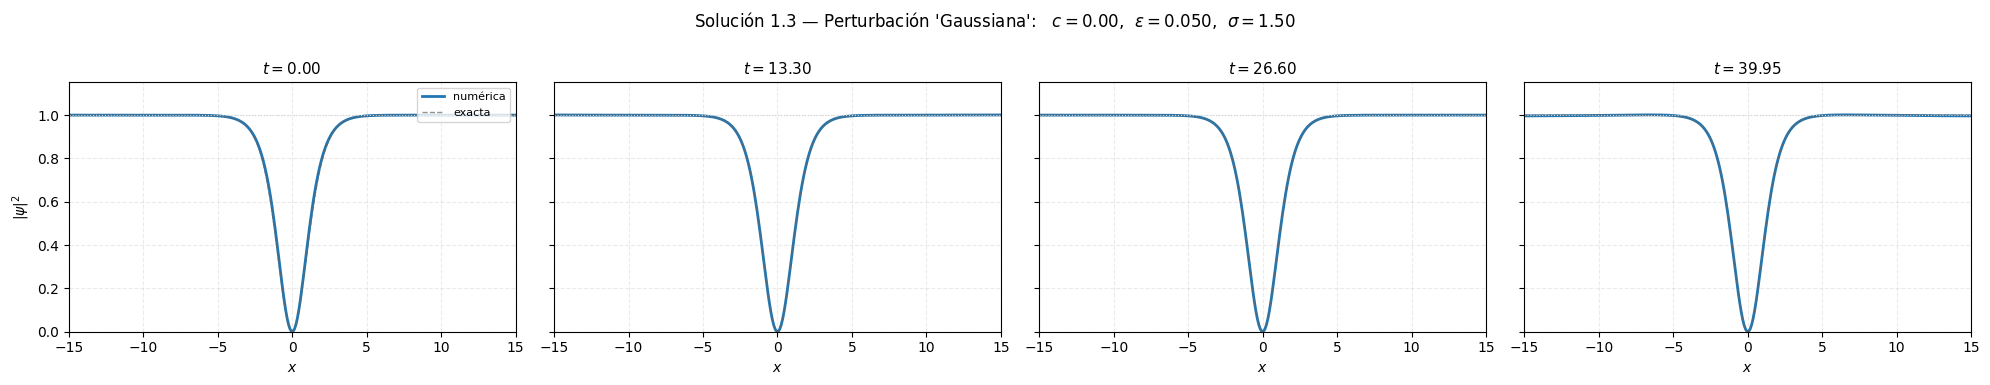

In [28]:

res_paper_c0 = simular_13p(c=0.0, tipo_pert='Gaussiana', epsilon=0.05, sigma=1.5,
                           T=40.0, dt=0.05, L=40, N=800, n_snapshots=4)

graficar_133(res_paper_c0, densidad=True)


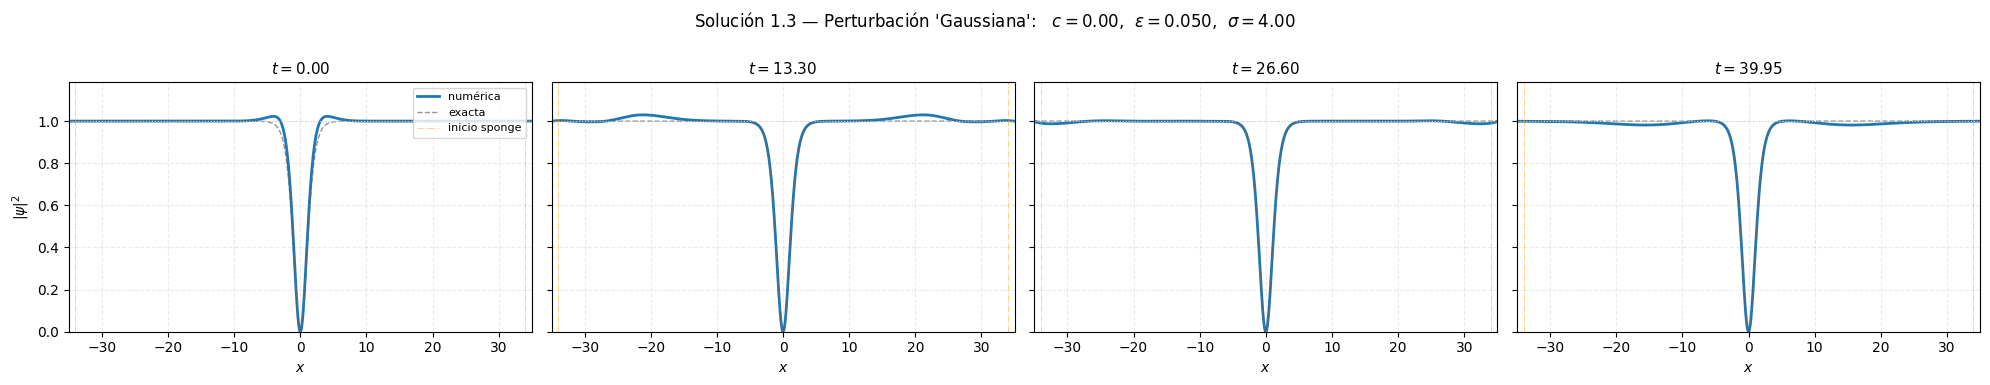

In [34]:
res_paper_c1 = simular_13p(c=0.0, tipo_pert='Gaussiana', epsilon=0.05, sigma=4,
                           T=40.0, dt=0.05, L=40, N=800, n_snapshots=4)

graficar_133(res_paper_c1, densidad=True, x_rango=(-35, 35))

---
# Solución 1.2 — Sistema acoplado (namespace `_12`)

$$i\partial_t\psi = \partial_{xx}\psi + \psi(1-|\psi|^2-\alpha|\phi|^2)$$
$$i\partial_t\phi = \partial_{xx}\phi + \phi(1-\alpha|\psi|^2-\beta|\phi|^2)$$

Todas las funciones de esta sección usan sufijo `_12` para no chocar con las de la Solución 1.3 de arriba.

## Parámetros y solución exacta

In [35]:


def parametros_sol12(alpha, beta, c):
    den1, den2 = 2*(beta-alpha), beta-alpha**2
    b2   = den2/den1 - c**2/4
    A1sq = 1 - c**2*(beta-alpha)/(2*den2)
    B1sq = c**2*(beta-alpha)/(2*den2)
    A2sq = (alpha-1)*(2*den2 - c**2*(beta-alpha))/(den1*den2)
    lam  = alpha - 1 - den2/den1 + c**2/4

    # --- avisos de existencia (todos los parametros, no solo b^2 y A2^2) ---
    if b2   <= 0: print(f"[aviso] b^2={b2:.3g} <= 0   -> fuera de la region de existencia.")
    if A1sq <  0: print(f"[aviso] A1^2={A1sq:.3g} < 0  -> fondo oscuro mal definido (|c| demasiado grande).")
    if B1sq <  0: print(f"[aviso] B1^2={B1sq:.3g} < 0  -> fuera de la region de existencia.")
    if A2sq <= 0: print(f"[aviso] A2^2={A2sq:.3g} <= 0 -> phi=0 (degenerado, p.ej. alpha=1).")

    b  = np.sqrt(b2)    if b2   > 0 else np.nan
    A1 = np.sqrt(A1sq)  if A1sq > 0 else 0.0
    B1 = -np.sqrt(B1sq) if B1sq > 0 else 0.0     # signo corregido (-i)
    A2 = np.sqrt(A2sq)  if A2sq > 0 else 0.0
    return A1, b, B1, A2, lam


def solucion_exacta12(x, par, c, t):
    A1, b, B1, A2, lam = par
    xi  = x - c*t
    psi = A1*np.tanh(b*xi) + 1j*B1
    phi = A2/np.cosh(b*xi) * np.exp(1j*((lam + c**2/4)*t - c*x/2))
    return psi, phi

## Grilla y esquemas temporales — Solución 1.2

Mismas dos correcciones que en la Sección 1.3: `r=1/(2h²)` y sponge post-paso sobre la desviación del fondo.

In [36]:
def construir_grilla_12(L=40, N=800, w=6.0, eta0=3.0):
    x = np.linspace(-L, L, N); h = x[1]-x[0]
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    return x, h, eta


def _lap(f, h):
    d2 = np.zeros_like(f)
    d2[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2])/h**2
    return d2


def paso_CN_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg, n_iter=6):
    N = len(psi); r = 1.0/(2*h**2)
    pk, fk = psi.copy(), phi.copy()
    for _ in range(n_iter):
        pm, fm = (psi+pk)/2, (phi+fk)/2
        Vp = 1 - np.abs(pm)**2 - alpha*np.abs(fm)**2
        Vf = 1 - alpha*np.abs(pm)**2 - beta*np.abs(fm)**2
        for src, V, bi, bd, tag in [(psi, Vp, psi_bg[0], psi_bg[-1], 'p'),
                                    (phi, Vf, phi_bg[0], phi_bg[-1], 'f')]:
            rhs  = 1j/dt*src + r*(np.roll(src,1)-2*src+np.roll(src,-1)) + (V/2)*src
            diag = 1j/dt + 2*r - V/2
            ab = np.zeros((3,N), complex); ab[0,1:]=-r; ab[1,:]=diag; ab[2,:-1]=-r
            ab[1,0]=1; ab[0,1]=0; rhs[0]=bi; ab[1,-1]=1; ab[2,-2]=0; rhs[-1]=bd
            sol = solve_banded((1,1), ab, rhs)
            if tag=='p': pk = sol
            else:        fk = sol
    am = np.exp(-eta*dt)
    return psi_bg + (pk-psi_bg)*am, phi_bg + (fk-phi_bg)*am


def paso_RK4_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg):
    def F(p, f):
        Fp = -1j*(_lap(p,h) + p*(1-np.abs(p)**2-alpha*np.abs(f)**2))
        Ff = -1j*(_lap(f,h) + f*(1-alpha*np.abs(p)**2-beta*np.abs(f)**2))
        return Fp, Ff
    p1,f1 = F(psi,phi)
    p2,f2 = F(psi+0.5*dt*p1, phi+0.5*dt*f1)
    p3,f3 = F(psi+0.5*dt*p2, phi+0.5*dt*f2)
    p4,f4 = F(psi+dt*p3,     phi+dt*f3)
    psi = psi + dt/6*(p1+2*p2+2*p3+p4)
    phi = phi + dt/6*(f1+2*f2+2*f3+f4)
    psi[0],psi[-1] = psi_bg[0],psi_bg[-1]
    phi[0],phi[-1] = phi_bg[0],phi_bg[-1]
    am = np.exp(-eta*dt)
    return psi_bg + (psi-psi_bg)*am, phi_bg + (phi-phi_bg)*am


## Función de simulación — Solución 1.2 (`simular_12`)

In [37]:
def simular_12(alpha=-1.0, beta=-2.0, c=0.0, tipo_pert='paper',
               q=3e-4, epsilon=0.05, sigma=3.0, q_phi=0.0,
               T=20.0, dt=0.005, L=40, N=800, n_snapshots=6):
    par = parametros_sol12(alpha, beta, c)
    A1, b, B1, A2, lam = par
    x, h, eta = construir_grilla_12(L=L, N=N)
    nt = int(T/dt)
    idx_guardar = np.linspace(0, nt-1, n_snapshots, dtype=int)

    psi_sol, phi_sol = solucion_exacta12(x, par, c, t=0)
    if   tipo_pert == 'paper':     psi = psi_sol + perturbacion_paper(x, q=q)
    elif tipo_pert == 'gaussiana': psi = perturbacion_gaussiana(psi_sol, x, epsilon, sigma)
    else:                          psi = psi_sol.copy()
    phi = phi_sol + q_phi*np.exp(-x**2/sigma**2)    # semilla opcional en phi

    PSI = np.zeros((n_snapshots, N), complex)
    PHI = np.zeros((n_snapshots, N), complex)
    tiempos = np.zeros(n_snapshots); idx_snap = 0

    for n in range(nt):
        t = n*dt
        if idx_snap < n_snapshots and n == idx_guardar[idx_snap]:
            PSI[idx_snap], PHI[idx_snap], tiempos[idx_snap] = psi, phi, t
            idx_snap += 1
            if idx_snap == n_snapshots: break
        psi_bg, phi_bg = solucion_exacta12(x, par, c, t=t)
        if abs(c) < 1e-10:
            psi, phi = paso_CN_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg)
        else:
            psi, phi = paso_RK4_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg)

    return dict(x=x, h=h, t=tiempos, PSI=PSI, PHI=PHI, psi_sol=psi_sol, phi_sol=phi_sol,
                alpha=alpha, beta=beta, c=c, A1=A1, b=b, B1=B1, A2=A2, lam=lam, L=L)


## Gráfico — Solución 1.2 (`graficar_12`)

Apila $\psi$ (fila superior) y $\phi$ (fila inferior), una columna por snapshot, con color fijo `COLOR_NUM` para la curva numérica en todos los paneles.

In [38]:
def graficar_12(res, densidad=True, x_rango=None, x_sponge=None):
    """
    psi (fila superior) y phi (fila inferior), una columna por snapshot.
    densidad=True -> |.|^2 ; False -> |.|
    """
    x, t, c, L = res['x'], res['t'], res['c'], res['L']
    par = (res['A1'], res['b'], res['B1'], res['A2'], res['lam'])
    n = len(t)
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    ylab = {'psi': r'$|\psi|^2$' if densidad else r'$|\psi|$',
            'phi': r'$|\phi|^2$' if densidad else r'$|\phi|$'}

    if x_rango is None:
        margen = min(max(15, abs(c)*t[-1] + 10), L)
        x_rango = (-margen, margen)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede [-{L},{L}]. Se recorta.")
            x_rango = (max(x_min,-L), min(x_max,L))
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None: x_sponge = 0.85*L

    ymax_psi = 1.15
    pico = res['A2']**2 if densidad else res['A2']
    ymax_phi = 1.15*pico if pico > 0 else 1.0

    fig, axes = plt.subplots(2, n, figsize=(5*n, 7.6), sharex=True, squeeze=False)
    for k in range(n):
        t_k = t[k]
        psi_ex, phi_ex = solucion_exacta12(x, par, c, t_k)
        filas = [('psi', res['PSI'][k], psi_ex, 1.0,  ymax_psi),
                 ('phi', res['PHI'][k], phi_ex, None, ymax_phi)]
        for fila, (comp, campo_num, campo_ex, fondo, ymax) in enumerate(filas):
            ax = axes[fila][k]
            ax.plot(x[mask], f(campo_num[mask]), color=COLOR_NUM, lw=2, label='numérica')
            ax.plot(x[mask], f(campo_ex[mask]), color=COLOR_EX, lw=1, ls='--', alpha=0.7, label='exacta')
            if fondo is not None: ax.axhline(fondo, color='lightgray', lw=0.8, ls=':')
            for xs, lab in [(x_sponge, None), (-x_sponge, 'inicio sponge' if k==0 else None)]:
                if x_rango[0] <= xs <= x_rango[1]:
                    ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
            if abs(c) > 0.01:
                ax.axvline(c*t_k, color='red', lw=0.8, ls=':', alpha=0.7,
                           label=r'$x=ct$' if k==0 else None)
            if fila == 0: ax.set_title(rf'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
            ax.set_ylabel(ylab[comp]); ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
            ax.grid(True, alpha=0.25, ls='--')
            if k == 0: ax.legend(fontsize=8, loc='upper right')
        axes[1][k].set_xlabel('$x$')

    fig.suptitle(rf"Solución 1.2 — ψ (arriba) y φ (abajo)   "
                 rf"($\alpha={res['alpha']:.0f},\ \beta={res['beta']:.0f},\ c={res['c']:.0f}$)", y=1.01)
    plt.tight_layout()
    plt.show()


In [39]:
def graficar_122(res, densidad=True, x_rango=None, x_sponge=None, margen=1.15, ymax_fijo=None):
    """
    psi (fila superior) y phi (fila inferior), una columna por snapshot.
    densidad=True -> |.|^2 ; False -> |.|

    margen:    factor multiplicativo sobre el maximo real de cada campo (default 15% de aire)
    ymax_fijo: dict opcional {'psi': valor, 'phi': valor} para forzar limites manuales
               (si querés comparar varias figuras con la misma escala)
    """
    x, t, c, L = res['x'], res['t'], res['c'], res['L']
    par = (res['A1'], res['b'], res['B1'], res['A2'], res['lam'])
    n = len(t)
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    ylab = {'psi': r'$|\psi|^2$' if densidad else r'$|\psi|$',
            'phi': r'$|\phi|^2$' if densidad else r'$|\phi|$'}

    if x_rango is None:
        margen_x = min(max(15, abs(c)*t[-1] + 10), L)
        x_rango = (-margen_x, margen_x)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede [-{L},{L}]. Se recorta.")
            x_rango = (max(x_min,-L), min(x_max,L))
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None: x_sponge = 0.85*L

    # --- limites dinamicos: maximo REAL de los datos (numerico + exacto), en toda la ventana ---
    if ymax_fijo is not None and 'psi' in ymax_fijo:
        ymax_psi = ymax_fijo['psi']
    else:
        ymax_psi = max(1.0, f(res['PSI'][:, mask]).max()) * margen

    if ymax_fijo is not None and 'phi' in ymax_fijo:
        ymax_phi = ymax_fijo['phi']
    else:
        pico_ex = res['A2']**2 if densidad else res['A2']
        ymax_phi = max(pico_ex, f(res['PHI'][:, mask]).max(), 1e-6) * margen

    fig, axes = plt.subplots(2, n, figsize=(5*n, 7.6), sharex=True, squeeze=False)
    for k in range(n):
        t_k = t[k]
        psi_ex, phi_ex = solucion_exacta12(x, par, c, t_k)
        filas = [('psi', res['PSI'][k], psi_ex, 1.0,  ymax_psi),
                 ('phi', res['PHI'][k], phi_ex, None, ymax_phi)]
        for fila, (comp, campo_num, campo_ex, fondo, ymax) in enumerate(filas):
            ax = axes[fila][k]
            ax.plot(x[mask], f(campo_num[mask]), color=COLOR_NUM, lw=2, label='numérica')
            ax.plot(x[mask], f(campo_ex[mask]), color=COLOR_EX, lw=1, ls='--', alpha=0.7, label='exacta')
            if fondo is not None: ax.axhline(fondo, color='lightgray', lw=0.8, ls=':')
            for xs, lab in [(x_sponge, None), (-x_sponge, 'inicio sponge' if k==0 else None)]:
                if x_rango[0] <= xs <= x_rango[1]:
                    ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
            if abs(c) > 0.01:
                ax.axvline(c*t_k, color='red', lw=0.8, ls=':', alpha=0.7,
                           label=r'$x=ct$' if k==0 else None)
            if fila == 0: ax.set_title(rf'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
            ax.set_ylabel(ylab[comp]); ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
            ax.grid(True, alpha=0.25, ls='--')
            if k == 0: ax.legend(fontsize=8, loc='upper right')
        axes[1][k].set_xlabel('$x$')

    fig.suptitle(rf"Solución 1.2 — ψ (arriba) y φ (abajo)   "
                 rf"($\alpha={res['alpha']:.2f},\ \beta={res['beta']:.2f},\ c={res['c']:.2f}$)", y=1.01)
    plt.tight_layout()
    plt.show()

## Sponge — visualización

Verifica visualmente que $\eta(x)$ sea 0 en el interior y monótono creciente hacia el borde.

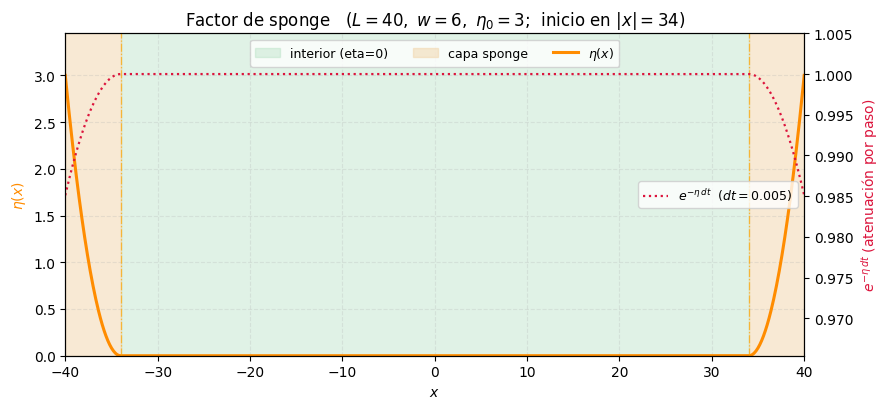

In [40]:
def graficar_sponge(L=40, N=800, w=6.0, eta0=3.0, dt=None):
    """Visualiza el factor de sponge eta(x) usado en la simulacion."""
    x   = np.linspace(-L, L, N)
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    x_on = L - w

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.axvspan(-x_on, x_on, color="#a8dbb8", alpha=0.35, label="interior (eta=0)")
    ax.axvspan(-L, -x_on,  color="#f0d0a0", alpha=0.45, label="capa sponge")
    ax.axvspan( x_on,  L,  color="#f0d0a0", alpha=0.45)

    ax.plot(x, eta, color="darkorange", lw=2.2, label=r"$\eta(x)$")
    for xs in (x_on, -x_on):
        ax.axvline(xs, color="orange", lw=0.9, ls="-.", alpha=0.7)

    ax.set_xlabel("$x$"); ax.set_ylabel(r"$\eta(x)$", color="darkorange")
    ax.set_xlim(-L, L); ax.set_ylim(0, eta0*1.15)
    ax.set_title(rf"Factor de sponge   ($L={L},\ w={w},\ \eta_0={eta0}$;  "
                 rf"inicio en $|x|={x_on:.0f}$)")
    ax.grid(True, alpha=0.25, ls="--")

    if dt is not None:
        ax2 = ax.twinx()
        ax2.plot(x, np.exp(-eta*dt), color="crimson", lw=1.6, ls=":",
                 label=rf"$e^{{-\eta\,dt}}$  ($dt={dt}$)")
        ax2.set_ylabel(r"$e^{-\eta\,dt}$ (atenuación por paso)", color="crimson")
        ax2.set_ylim(np.exp(-eta0*dt)*0.98, 1.005)
        ax2.legend(loc="center right", fontsize=9)

    ax.legend(loc="upper center", fontsize=9, ncol=3)
    plt.tight_layout()
    plt.show()

graficar_sponge(L=40, w=6, eta0=3, dt=0.005)


## Experimentos — Solución 1.2 (sistema acoplado)



**Perturbación de $\psi$** — multiplicativa gaussiana:

$$
\psi_0(x) = \psi_{\text{sol}}(x)\left[1 + \varepsilon\, e^{-x^2/\sigma^2}\right], \qquad \varepsilon = 0.05,\ \ \sigma = 3
$$

Reescala localmente la amplitud del soliton oscuro en torno a $x=0$, sin alterar su estructura lejos de esa región.

**Perturbación de $\phi$** — aditiva gaussiana:

$$
\phi_0(x) = \phi_{\text{sol}}(x) + q_\phi\, e^{-x^2/\sigma^2}, \qquad q_\phi = 5\times10^{-3}
$$

Introduce una pequeña semilla adicional sobre el pico del componente brillante.

A partir del dato inicial perturbado $(\psi_0,\phi_0)$ se integra el sistema en $x\in[-40,40]$ ($N=800$ puntos), con paso temporal $dt=5\times10^{-3}$, hasta $T=100$, registrando $12$ instantáneas equiespaciadas de $|\psi(x,t)|^2$ y $|\phi(x,t)|^2$. Estas se comparan en cada instante contra el perfil exacto $(\psi_{\text{sol}}, \phi_{\text{sol}})$: si la solución numérica permanece cerca de la curva exacta durante toda la ventana temporal, esto es evidencia numérica de estabilidad orbital de la Solución 1.2 frente a esta perturbación.

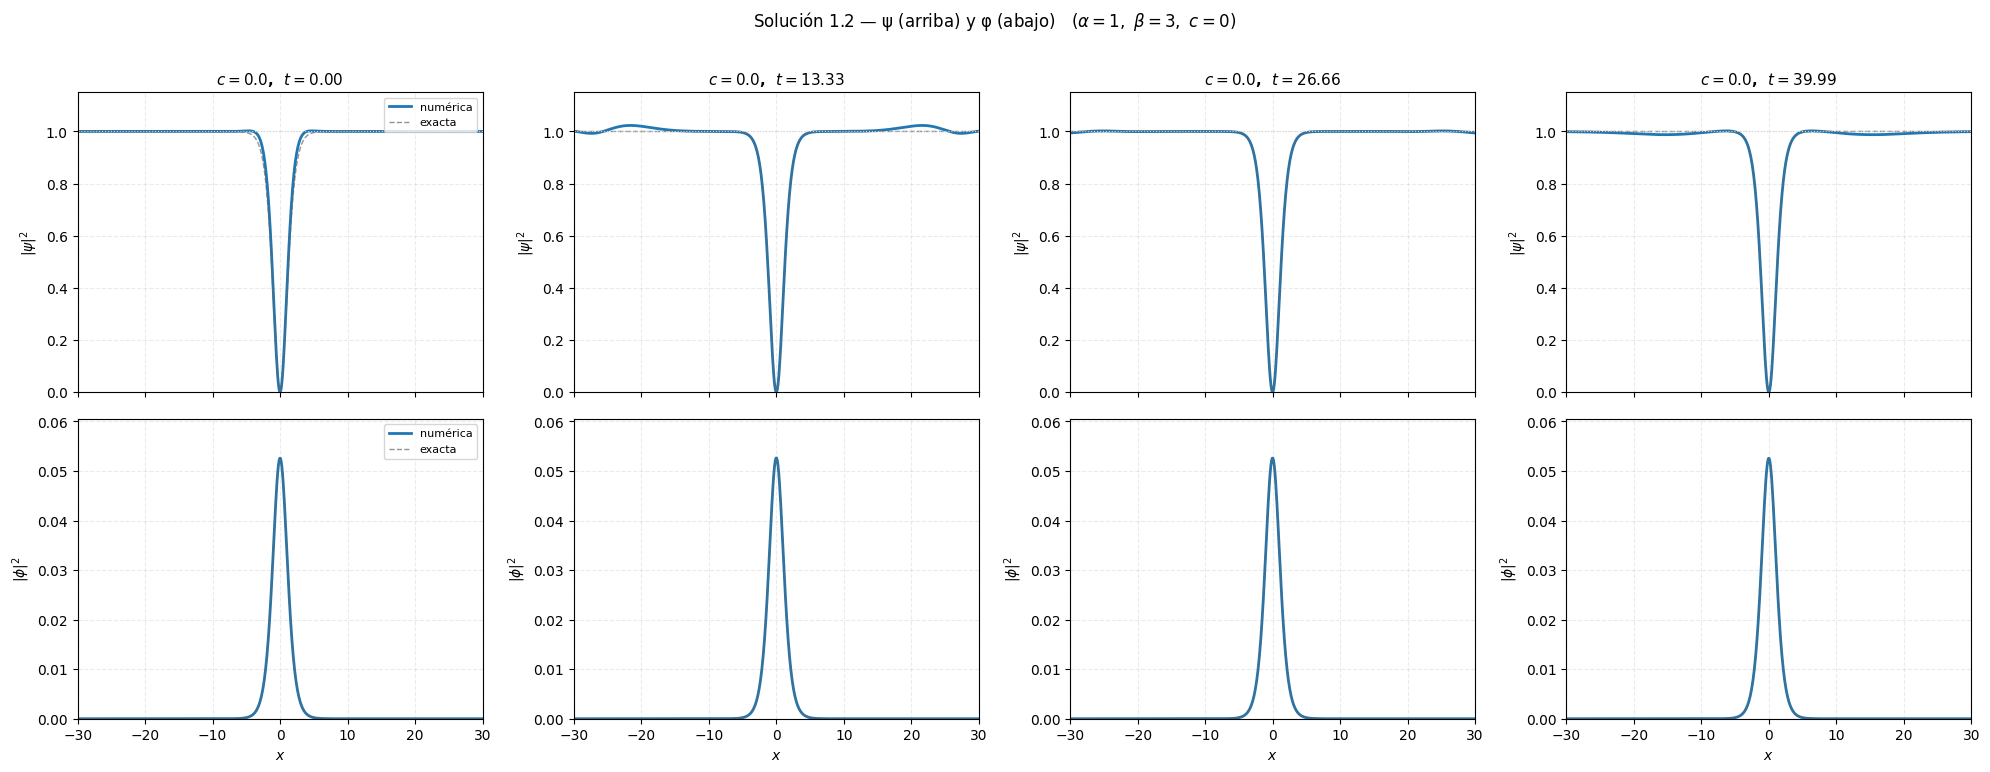

In [47]:

res_verif12 = simular_12(alpha=1.1, beta=3, c=0.0, tipo_pert='gaussiana',epsilon=0.05,sigma=3,q_phi=0,
                         T=40.0, dt=0.005, L=40, N=800, n_snapshots=4)
graficar_12(res_verif12, densidad=True,x_rango=(-30, 30))


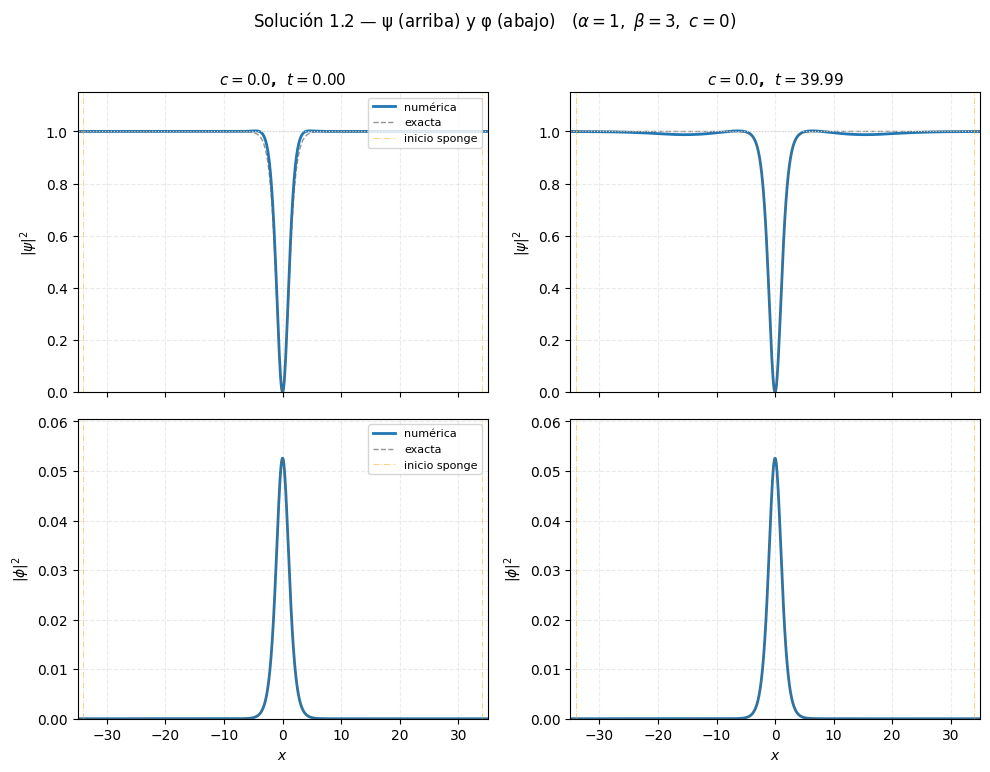

In [46]:

res_verif12 = simular_12(alpha=1.1, beta=3, c=0.0, tipo_pert='gaussiana',epsilon=0.05,sigma=3,q_phi=0,
                         T=40.0, dt=0.005, L=40, N=800, n_snapshots=2)
graficar_12(res_verif12, densidad=True,x_rango=(-35, 35))


##Caso desacoplado con perturbacion en $\phi$

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

COLOR_NUM = "#1f77b4"
COLOR_EX  = "0.4"

def grilla(L=60.0, N=1200):
    x = np.linspace(-L, L, N)
    return x, x[1] - x[0]

def sponge(x, L, w=6.0, eta0=3.0):
    """0 en el interior, crece cuadraticamente hasta eta0 en el borde."""
    return eta0 * np.clip((np.abs(x) - (L - w)) / w, 0.0, 1.0) ** 2

def params_13(c):
    """Perfil exacto Sol 1.3 (phi=0). Existencia |c| < sqrt(2)."""
    if abs(c) >= np.sqrt(2):
        raise ValueError("|c| debe ser < sqrt(2)")
    A1 = np.sqrt(1.0 - c**2 / 2.0)
    b  = np.sqrt((2.0 - c**2) / 4.0)
    B1 = -c / np.sqrt(2.0)
    return A1, b, B1

def psi_exacta_13(x, t, c):
    A1, b, B1 = params_13(c)
    return A1 * np.tanh(b * (x - c * t)) + 1j * B1

def _cn_tridiag(u_old, F, h, dt, bc_izq, bc_der):
    """
    Un paso CN de  i u_t = u_xx + F u  con F real dado (congelado en n+1/2).
    Dirichlet: u[0]=bc_izq, u[-1]=bc_der.
    """
    N  = u_old.size
    r  = 1.0 / h**2
    ab = np.zeros((3, N), dtype=complex)

    # A = (i/dt) I - (1/2)(D2 + diag(F))
    ab[0, 1:]  = -0.5 * r                      # superdiagonal
    ab[1, :]   = 1j / dt - 0.5 * (-2.0 * r + F)  # diagonal
    ab[2, :-1] = -0.5 * r                      # subdiagonal

    # RHS = (i/dt) u^n + (1/2)(D2 u^n + F u^n)
    d2 = np.zeros(N, dtype=complex)
    d2[1:-1] = (u_old[2:] - 2.0 * u_old[1:-1] + u_old[:-2]) * r
    rhs = 1j / dt * u_old + 0.5 * (d2 + F * u_old)

    # filas de borde -> identidad
    ab[1, 0]  = 1.0; ab[0, 1]  = 0.0
    ab[1, -1] = 1.0; ab[2, -2] = 0.0
    rhs[0], rhs[-1] = bc_izq, bc_der

    return solve_banded((1, 1), ab, rhs)

def paso_acoplado(psi, phi, x, h, dt, t, c, alpha, beta, eta, n_iter=2):
    """
    CN semi-implicito con punto fijo sobre la no linealidad.
    i psi_t = psi_xx + psi(1 - |psi|^2 - alpha|phi|^2)
    i phi_t = phi_xx + phi(1 - alpha|psi|^2 - beta|phi|^2)
    """
    psi_bc_i = psi_exacta_13(x[0],  t + dt, c)
    psi_bc_d = psi_exacta_13(x[-1], t + dt, c)

    psi_new, phi_new = psi.copy(), phi.copy()
    for _ in range(n_iter):
        p2 = 0.5 * (np.abs(psi)**2 + np.abs(psi_new)**2)   # |psi|^2 en n+1/2
        q2 = 0.5 * (np.abs(phi)**2 + np.abs(phi_new)**2)   # |phi|^2 en n+1/2
        F = 1.0 - p2 - alpha * q2
        G = 1.0 - alpha * p2 - beta * q2
        psi_new = _cn_tridiag(psi, F, h, dt, psi_bc_i, psi_bc_d)
        phi_new = _cn_tridiag(phi, G, h, dt, 0.0 + 0j, 0.0 + 0j)

    # sponge multiplicativo sobre la desviacion del fondo exacto
    psi_bg  = psi_exacta_13(x, t + dt, c)
    amort   = np.exp(-eta * dt)
    psi_new = psi_bg + (psi_new - psi_bg) * amort
    phi_new = phi_new * amort
    return psi_new, phi_new

In [50]:
def simular_semilla(alpha, beta, c=0.0, epsilon=0.05, sigma=3.0,
                    T=40.0, dt=0.005, L=60.0, N=1200,
                    n_snapshots=6, w=6.0, eta0=3.0, verbose=True):
    """
    psi = dark soliton exacto (Sol 1.3, sin perturbar).
    phi = epsilon * exp(-x^2/sigma^2)  (semilla infinitesimal).
    Mide si phi queda atrapada en el nucleo o es expulsada.
    """
    x, h = grilla(L, N)
    eta  = sponge(x, L, w=w, eta0=eta0)
    A1, b, B1 = params_13(c)

    psi = psi_exacta_13(x, 0.0, c)
    phi = epsilon * np.exp(-x**2 / sigma**2) + 0j

    nt   = int(round(T / dt))
    idxs = set(np.linspace(0, nt, n_snapshots, dtype=int).tolist())

    nucleo = np.abs(x - c * 0.0) < 3.0 / b   # se recentra abajo
    def masa(u, m=None):
        return np.trapezoid(np.abs(u[m] if m is not None else u)**2,
                            x[m] if m is not None else x)

    Nphi0 = masa(phi)
    PSI, PHI, ts = [], [], []
    t_hist, Nphi_h, Nnuc_h, Npsi_h = [], [], [], []

    for n in range(nt + 1):
        t = n * dt
        if n in idxs:
            PSI.append(psi.copy()); PHI.append(phi.copy()); ts.append(t)
        nuc = np.abs(x - c * t) < 3.0 / b
        t_hist.append(t)
        Nphi_h.append(masa(phi) / Nphi0)
        Nnuc_h.append(masa(phi, nuc) / Nphi0)
        Npsi_h.append(np.trapezoid(np.abs(np.abs(psi)**2 - 1.0), x))
        if n < nt:
            psi, phi = paso_acoplado(psi, phi, x, h, dt, t, c, alpha, beta, eta)

    res = dict(x=x, t=np.array(ts), PSI=PSI, PHI=PHI, c=c, L=L, w=w, b=b,
               alpha=alpha, beta=beta, epsilon=epsilon,
               t_hist=np.array(t_hist), Nphi=np.array(Nphi_h),
               Nnuc=np.array(Nnuc_h), Npsi=np.array(Npsi_h))

    # --- diagnosticos ---
    n_early = int(round(min(T, 0.3 * (L - w) / 1.0) / dt))  # antes de tocar el sponge
    deriva  = abs(res['Nphi'][n_early] - 1.0)
    res.update(deriva_temprana=deriva,
               frac_total=res['Nphi'][-1],
               frac_nucleo=res['Nnuc'][-1],
               amp_rel=np.max(np.abs(PHI[-1])) / epsilon)

    if verbose:
        print(f"alpha={alpha:+.2f}  beta={beta:+.2f}  eps={epsilon:.3f}  c={c:.2f}")
        print(f"  deriva de N_phi (t<{n_early*dt:.0f}, pre-sponge) : {deriva:.2e}")
        print(f"  masa total retenida  N_phi(T)/N_phi(0)         : {res['frac_total']:.4f}")
        print(f"  masa en el nucleo (|x-ct| < 3/b)               : {res['frac_nucleo']:.4f}")
        print(f"  max|phi|(T) / eps                              : {res['amp_rel']:.4f}")
    return res

In [51]:
def graficar_semilla_12(res, n_cols=3, densidad=True, x_rango=None,
                        normalizar_phi=True):
    """
    Estilo graficar_12: fila superior psi, fila inferior phi.
    normalizar_phi=True grafica phi/epsilon (o |phi|^2/eps^2) para que
    la semilla sea visible junto a |psi|^2 ~ 1.
    """
    PSI, PHI, t, x = res['PSI'], res['PHI'], res['t'], res['x']
    eps, c, L = res['epsilon'], res['c'], res['L']
    n = len(t); n_filas = int(np.ceil(n / n_cols))
    xs = 0.85 * L

    f = (lambda u: np.abs(u)**2) if densidad else (lambda u: np.abs(u))
    esc = (eps**2 if densidad else eps) if normalizar_phi else 1.0

    # limites dinamicos compartidos por fila (comparables entre snapshots)
    ymax_psi = max(f(u).max() for u in PSI) * 1.12
    ymax_phi = max(f(u).max() for u in PHI) / esc * 1.12

    fig, ax = plt.subplots(2 * n_filas, n_cols,
                           figsize=(4.2 * n_cols, 3.0 * 2 * n_filas),
                           squeeze=False)

    for k in range(n):
        i, j = divmod(k, n_cols)
        a_psi, a_phi = ax[2 * i, j], ax[2 * i + 1, j]

        a_psi.plot(x, f(psi_exacta_13(x, t[k], c)), color=COLOR_EX, lw=1.6, ls='--')
        a_psi.plot(x, f(PSI[k]), color=COLOR_NUM, lw=1.3)
        a_phi.plot(x, f(PHI[k]) / esc, color=COLOR_NUM, lw=1.3)

        a_psi.set_ylim(0, ymax_psi)
        a_phi.set_ylim(0, ymax_phi)
        for a in (a_psi, a_phi):
            a.axvline(c * t[k], color='0.75', lw=0.8)
            a.axvline( xs, color='orange', ls='-.', lw=1.0)
            a.axvline(-xs, color='orange', ls='-.', lw=1.0)
            if x_rango: a.set_xlim(*x_rango)
        a_phi.set_xlabel(r'$x$')
        a_psi.set_title(rf'$t={t[k]:.1f}$', fontsize=10)

        if j == 0:
            a_psi.set_ylabel(r'$|\psi|^2$' if densidad else r'$|\psi|$')
            if normalizar_phi:
                a_phi.set_ylabel(r'$|\phi|^2/\varepsilon^2$' if densidad
                                 else r'$|\phi|/\varepsilon$')
            else:
                a_phi.set_ylabel(r'$|\phi|^2$' if densidad else r'$|\phi|$')

    for k in range(n, n_filas * n_cols):
        i, j = divmod(k, n_cols)
        ax[2 * i, j].axis('off'); ax[2 * i + 1, j].axis('off')

    fig.suptitle(rf"$\alpha={res['alpha']:.2f}$, $\beta={res['beta']:.2f}$, "
                 rf"$c={res['c']:.2f}$, $\varepsilon={eps:.3f}$", y=1.0)
    fig.tight_layout(); plt.show()

alpha=+3.50  beta=+16.00  eps=0.050  c=0.00
  deriva de N_phi (t<16, pre-sponge) : 3.14e-07
  masa total retenida  N_phi(T)/N_phi(0)         : 0.9932
  masa en el nucleo (|x-ct| < 3/b)               : 0.7509
  max|phi|(T) / eps                              : 1.2412


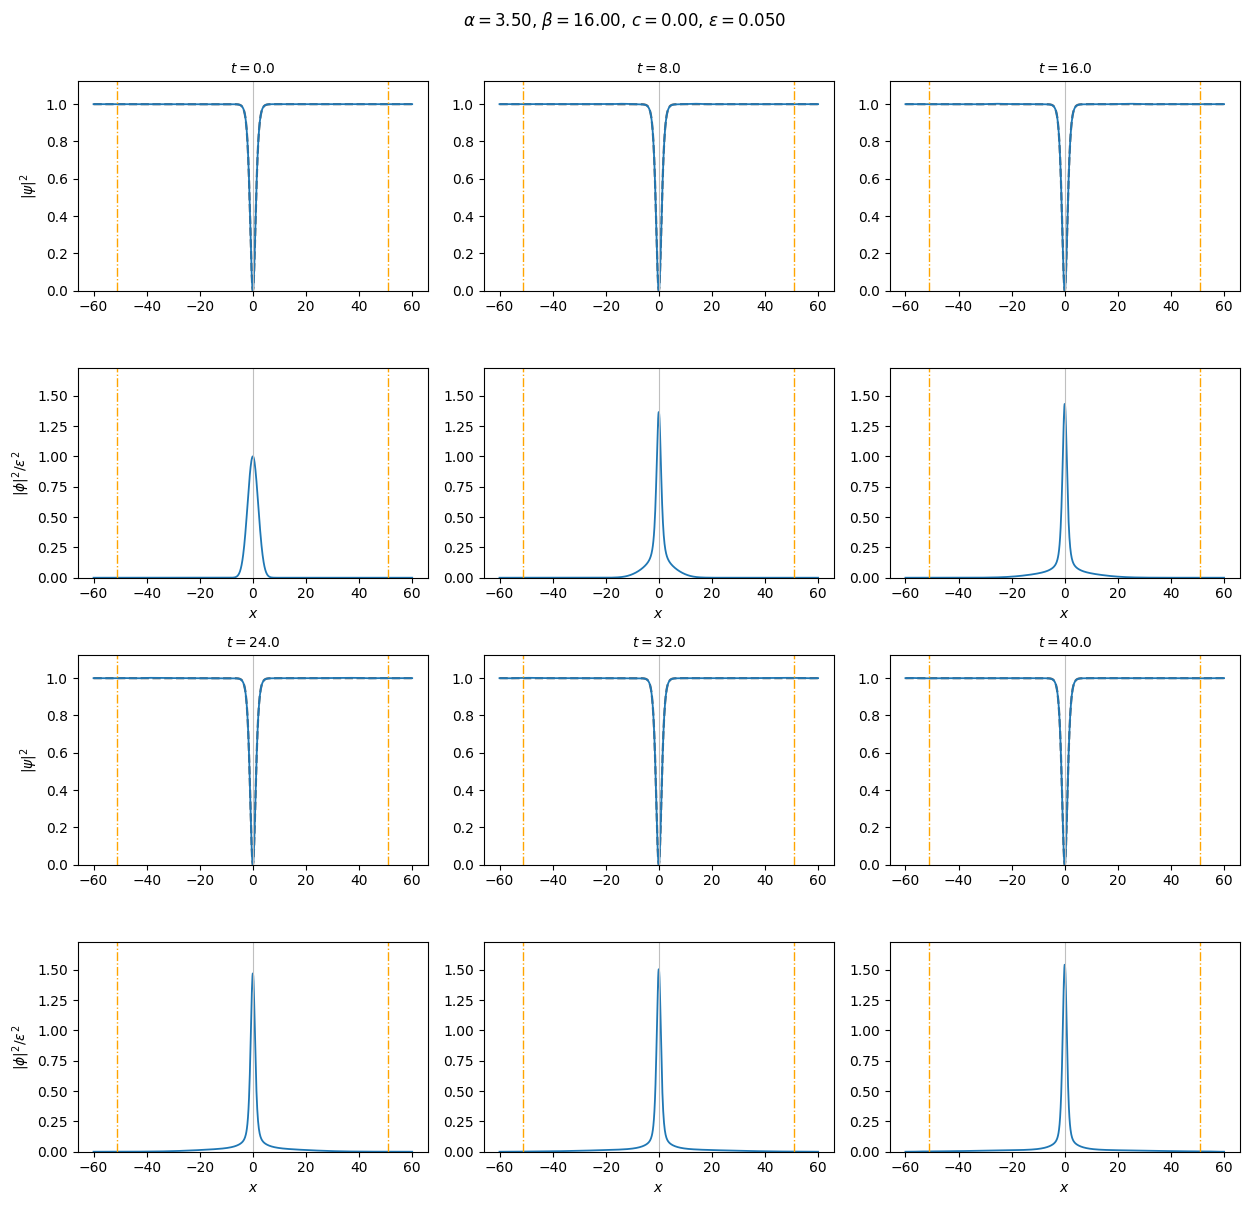

In [30]:
res = simular_semilla(alpha=3.5, beta=16, c=0.0, epsilon=0.05, sigma=-4,
                      T=40.0, L=60, N=1200, n_snapshots=6)
graficar_semilla_12(res)


In [31]:
def preparar_res(res):
    """Convierte PSI/PHI a arrays 2D y agrega A1,b,B1 (para compatibilidad con graficar_*)."""
    res = dict(res)
    res['PSI'] = np.asarray(res['PSI'])
    res['PHI'] = np.asarray(res['PHI'])
    A1, b, B1 = params_13(res['c'])
    res.update(A1=A1, b=b, B1=B1, A2=0.0, lam=None)
    return res

In [32]:
def graficar_semilla_122(res, densidad=True, x_rango=None, x_sponge=None,
                         margen=1.15, ymax_fijo=None, normalizar_phi=True):
    """
    psi (fila superior) y phi (fila inferior), una columna por snapshot.
    Estilo identico a graficar_122, adaptado al caso desacoplado:
      - phi exacta es identicamente 0 -> la referencia punteada es phi_0 (gaussiana)
      - normalizar_phi=True grafica |phi|^2/eps^2 para que la semilla sea visible
    """
    x, t, c, L = res['x'], res['t'], res['c'], res['L']
    eps = res['epsilon']
    n = len(t)
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    esc = (eps**2 if densidad else eps) if normalizar_phi else 1.0

    ylab = {'psi': r'$|\psi|^2$' if densidad else r'$|\psi|$',
            'phi': (r'$|\phi|^2/\varepsilon^2$' if densidad else r'$|\phi|/\varepsilon$')
                   if normalizar_phi else (r'$|\phi|^2$' if densidad else r'$|\phi|$')}

    if x_rango is None:
        margen_x = min(max(15, abs(c)*t[-1] + 10), L)
        x_rango = (-margen_x, margen_x)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede [-{L},{L}]. Se recorta.")
            x_rango = (max(x_min, -L), min(x_max, L))
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None: x_sponge = 0.85*L

    # --- limites dinamicos: maximo REAL de los datos, en toda la ventana ---
    if ymax_fijo is not None and 'psi' in ymax_fijo:
        ymax_psi = ymax_fijo['psi']
    else:
        ymax_psi = max(1.0, f(res['PSI'][:, mask]).max()) * margen
    if ymax_fijo is not None and 'phi' in ymax_fijo:
        ymax_phi = ymax_fijo['phi']
    else:
        ymax_phi = max(f(res['PHI'][:, mask]).max()/esc, 1e-6) * margen

    phi_ref = res['PHI'][0]   # gaussiana inicial, referencia fija

    fig, axes = plt.subplots(2, n, figsize=(5*n, 7.6), sharex=True, squeeze=False)
    for k in range(n):
        t_k = t[k]
        psi_ex = psi_exacta_13(x, t_k, c)
        filas = [('psi', res['PSI'][k], psi_ex,  1.0, 1.0, ymax_psi, 'exacta'),
                 ('phi', res['PHI'][k], phi_ref, 0.0, esc, ymax_phi, r'$\phi_0$')]
        for fila, (comp, campo_num, campo_ref, fondo, s, ymax, lab_ref) in enumerate(filas):
            ax = axes[fila][k]
            ax.plot(x[mask], f(campo_num[mask])/s, color=COLOR_NUM, lw=2, label='numérica')
            ax.plot(x[mask], f(campo_ref[mask])/s, color=COLOR_EX, lw=1, ls='--',
                    alpha=0.7, label=lab_ref)
            if fondo is not None:
                ax.axhline(fondo, color='lightgray', lw=0.8, ls=':')
            for xs, lab in [(x_sponge, None),
                            (-x_sponge, 'inicio sponge' if k == 0 else None)]:
                if x_rango[0] <= xs <= x_rango[1]:
                    ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
            if abs(c) > 0.01:
                ax.axvline(c*t_k, color='red', lw=0.8, ls=':', alpha=0.7,
                           label=r'$x=ct$' if k == 0 else None)
            if fila == 0:
                ax.set_title(rf'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
            ax.set_ylabel(ylab[comp]); ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
            ax.grid(True, alpha=0.25, ls='--')
            if k == 0: ax.legend(fontsize=8, loc='upper right')
        axes[1][k].set_xlabel('$x$')

    fig.suptitle(rf"Semilla en $\phi$ — ψ (arriba) y φ (abajo)   "
                 rf"($\alpha={res['alpha']:.2f},\ \beta={res['beta']:.2f},\ "
                 rf"c={res['c']:.2f},\ \varepsilon={eps:.3f}$)", y=1.01)
    plt.tight_layout()
    plt.show()

alpha=+3.50  beta=+16.00  eps=5.000  c=0.00
  deriva de N_phi (t<16, pre-sponge) : 4.69e-01
  masa total retenida  N_phi(T)/N_phi(0)         : 0.2744
  masa en el nucleo (|x-ct| < 3/b)               : 0.0206
  max|phi|(T) / eps                              : 0.1136


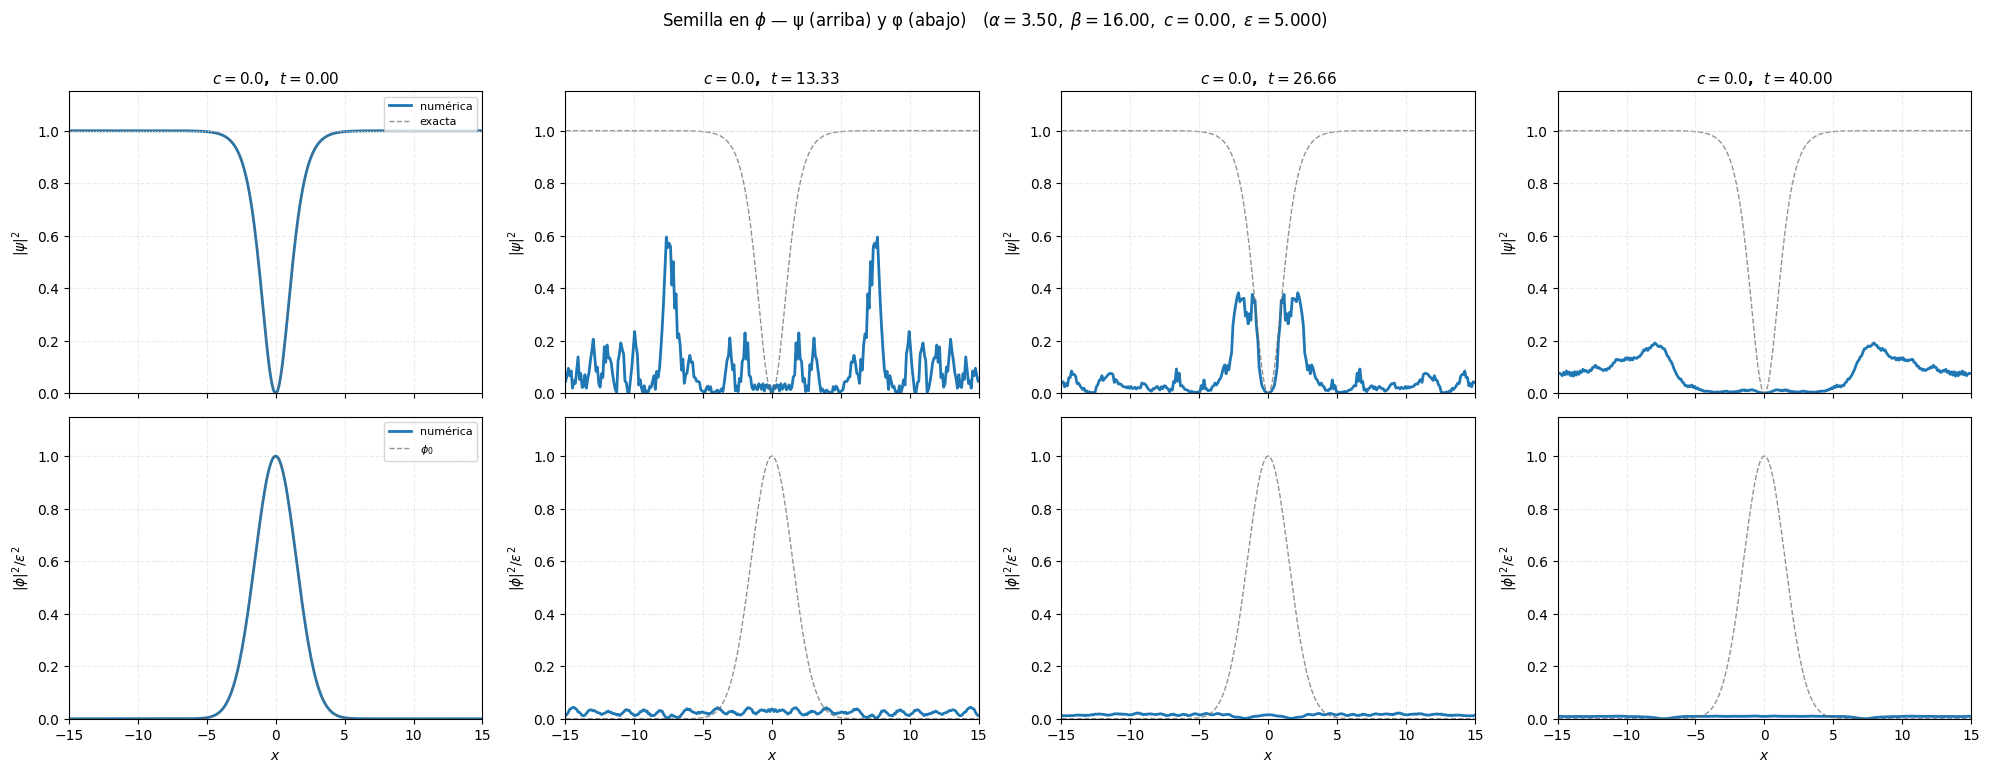

In [42]:
res = simular_semilla(alpha=3.5, beta=16, c=0.0, epsilon=5,sigma=3,
                      T=40.0, L=60, N=1200, n_snapshots=4)
res = preparar_res(res)
graficar_semilla_122(res)